In [1]:
# ============================================================
# ETAPA 1 - PREPARAR O CAMINHO DO PACOTE
# ============================================================
import os
import sys
from pathlib import Path

project_path = Path(".").resolve()

# Adiciona o diretório atual ao caminho do Python
if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

# Verifica se a pasta gravmag_codes existe
package_folder = project_path / "gravmag_codes"

if not package_folder.exists():
    raise FileNotFoundError(
        "A pasta 'gravmag_codes' não foi encontrada no mesmo diretório do notebook. "
        "Verifique se ela está na mesma pasta do arquivo .ipynb."
    )

print("Caminho preparado com sucesso!")
print("Diretório do projeto:", project_path)
print("Pasta do pacote:", package_folder)

Caminho preparado com sucesso!
Diretório do projeto: C:\Users\Usuario\Python_Notebooks\python-modeling
Pasta do pacote: C:\Users\Usuario\Python_Notebooks\python-modeling\gravmag_codes


In [2]:
# ============================================================
# ETAPA 2 - IMPORTAR OS MÓDULOS DO PACOTE
# ============================================================

from gravmag_codes import grids
from gravmag_codes import prism
from gravmag_codes import sphere
from gravmag_codes import cylinder
from gravmag_codes import hexagonalprism
from gravmag_codes import polygonalprism

from gravmag_codes import derivative
from gravmag_codes import filtering
from gravmag_codes import plotting
from gravmag_codes import synthetic
from gravmag_codes import inversion
from gravmag_codes import statistical

import numpy as np
import matplotlib.pyplot as plt

print("Módulos importados com sucesso!")

Módulos importados com sucesso!


In [3]:
# ============================================================
# ETAPA 3 - CRIAR O GRID DE OBSERVAÇÃO
# ============================================================

# Área do modelo em metros:
# [xmin, xmax, ymin, ymax]
area = [0.0, 10000.0, 0.0, 10000.0]

# Número de pontos em cada direção
shape = (101, 101)

# Nível de observação
# z positivo para baixo
observation_level = 0.0

# Criando o grid
x, y, z = synthetic.my_make_observation_grid(
    area=area,
    shape=shape,
    level=observation_level,
    flatten=False
)

print("Grid criado com sucesso!")
print("Shape de x:", x.shape)
print("Shape de y:", y.shape)
print("Shape de z:", z.shape)
print("X mínimo e máximo:", x.min(), x.max())
print("Y mínimo e máximo:", y.min(), y.max())
print("Z mínimo e máximo:", z.min(), z.max())

Grid criado com sucesso!
Shape de x: (101, 101)
Shape de y: (101, 101)
Shape de z: (101, 101)
X mínimo e máximo: 0.0 10000.0
Y mínimo e máximo: 0.0 10000.0
Z mínimo e máximo: 0.0 0.0


In [4]:
# ============================================================
# ETAPA 4 - CRIAR O MODELO SINTÉTICO COM DOIS PRISMAS
# ============================================================

# Centros dos prismas em metros
xprism = np.array([3000.0, 6500.0])
yprism = np.array([5000.0, 5500.0])

# Topo dos prismas em metros
top = np.array([500.0, 800.0])

# Base dos prismas em metros
bottom = np.array([2500.0, 3000.0])

# Dimensões horizontais dos prismas
deltax = 1000.0
deltay = 1000.0

# Densidades dos prismas em g/cm³
density = np.array([2.60, 2.85])

# Construção automática da lista de prismas
prisms = synthetic.my_synthetic_prism_model(
    centers_x=xprism,
    centers_y=yprism,
    top=top,
    bottom=bottom,
    dx=deltax,
    dy=deltay,
    density=density
)

print("Modelo sintético criado com sucesso!")
print("Número de prismas:", len(prisms))

for i, p in enumerate(prisms):
    print(f"Prisma {i+1}: {p}")

Modelo sintético criado com sucesso!
Número de prismas: 2
Prisma 1: [2500.0, 3500.0, 4500.0, 5500.0, 500.0, 2500.0, 2.6]
Prisma 2: [6000.0, 7000.0, 5000.0, 6000.0, 800.0, 3000.0, 2.85]


In [5]:
# ============================================================
# ETAPA 5 - CALCULAR O SINAL GRAVIMÉTRICO gz E PLOTAR
# ============================================================

# Calcula o sinal gravimétrico vertical dos prismas
gz = synthetic.my_forward_prisms_gz(
    x=x,
    y=y,
    z=z,
    prisms=prisms
)

print("Cálculo de gz finalizado!")
print("gz mínimo:", np.min(gz), "mGal")
print("gz máximo:", np.max(gz), "mGal")
print("gz médio:", np.mean(gz), "mGal")

Cálculo de gz finalizado!
gz mínimo: 0.32416375469014236 mGal
gz máximo: 21.840496527157413 mGal
gz médio: 3.2617092472045925 mGal


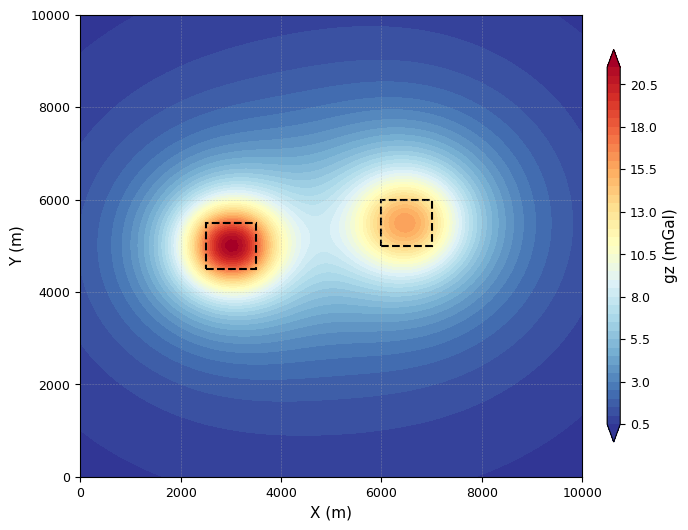

In [6]:
# Plot do mapa de gz
fig_gz, ax_gz, cf_gz = plotting.my_contourf(
    x=x,
    y=y,
    data=gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz (mGal)",
    colormap="RdYlBu_r",
    levels=50,
    #title="Anomalia gravimétrica vertical dos prismas"
)

# Desenha os contornos aproximados dos prismas no mapa
for p in prisms:
    # p = [xi, xf, yi, yf, top, bottom, density]
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_gz,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [9]:
# ============================================================
# ETAPA 6 - CALCULAR E PLOTAR O TILT ANGLE DO gz
# ============================================================

# Calcula o Tilt Angle em graus
# pad_factor, pad_mode e taper reduzem efeitos de borda no domínio de Fourier
tilt_gz = filtering.my_tilt(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    degrees=True,
    flatten=False
)

print("Tilt Angle calculado com sucesso!")
print("Tilt mínimo:", np.min(tilt_gz), "graus")
print("Tilt máximo:", np.max(tilt_gz), "graus")
print("Tilt médio:", np.mean(tilt_gz), "graus")

Tilt Angle calculado com sucesso!
Tilt mínimo: -89.96500794673632 graus
Tilt máximo: 88.7128922256253 graus
Tilt médio: -36.46221182888188 graus


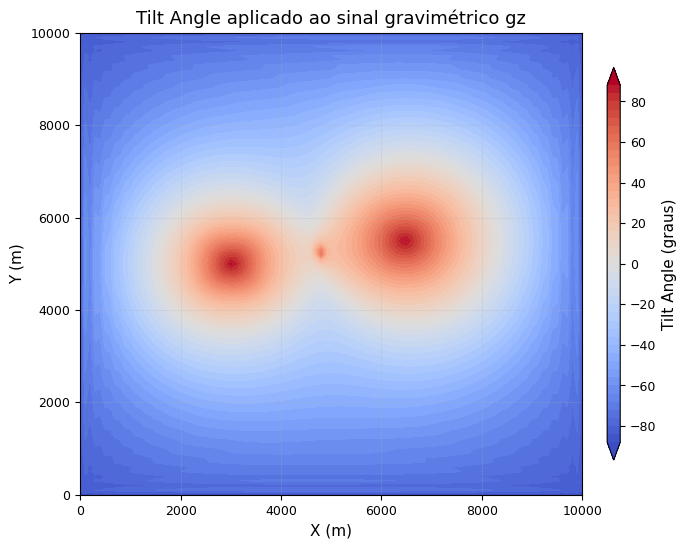

In [12]:
# Plot do Tilt Angle
fig_tilt, ax_tilt, cf_tilt = plotting.my_contourf(
    x=x,
    y=y,
    data=tilt_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Tilt Angle (graus)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Tilt Angle aplicado ao sinal gravimétrico gz"
)

# Contornos de referência: -45°, 0° e +45°
#plotting.my_contour(
#    x=x,
#    y=y,
#    data=tilt_gz,
#    ax=ax_tilt,
#    levels=[-45, 0, 45],
#    colors="black",
#    linewidths=1.0,
#    linestyles="-",
#    clabel=True,
#    clabel_fmt="%.0f°"
#)

# Desenha a projeção horizontal dos prismas
#for p in prisms:
#    plotting.my_draw_rectangle(
#        area=[p[0], p[1], p[2], p[3]],
#        ax=ax_tilt,
#        edgecolor="black",
#        facecolor="none",
#        linewidth=1.5,
#        linestyle="--"
#    )

plt.show()

In [13]:
# ============================================================
# ETAPA 7 - DERIVADAS HORIZONTAIS DO gz
# ============================================================

# Derivada horizontal em x: dgz/dx
gz_dx = derivative.my_xderiv(
    x=x,
    y=y,
    data=gz,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

# Derivada horizontal em y: dgz/dy
gz_dy = derivative.my_yderiv(
    x=x,
    y=y,
    data=gz,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivadas horizontais calculadas com sucesso!")
print("dgz/dx mínimo:", np.min(gz_dx))
print("dgz/dx máximo:", np.max(gz_dx))
print("dgz/dy mínimo:", np.min(gz_dy))
print("dgz/dy máximo:", np.max(gz_dy))

Derivadas horizontais calculadas com sucesso!
dgz/dx mínimo: -0.014337858133434146
dgz/dx máximo: 0.016006806693014353
dgz/dy mínimo: -0.01557599631457209
dgz/dy máximo: 0.01575713633651589


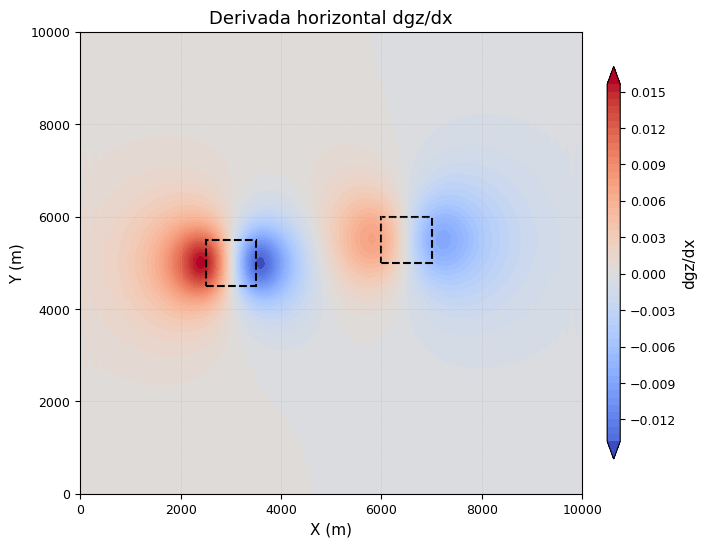

In [14]:
# ============================================================
# PLOT - DERIVADA HORIZONTAL dgz/dx
# ============================================================

fig_dx, ax_dx, cf_dx = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dx,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dgz/dx",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada horizontal dgz/dx"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dx,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

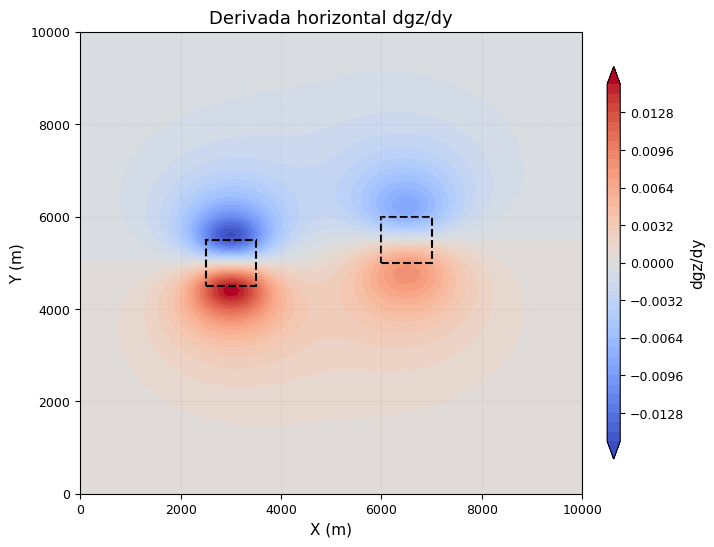

In [15]:
# ============================================================
# PLOT - DERIVADA HORIZONTAL dgz/dy
# ============================================================

fig_dy, ax_dy, cf_dy = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dy,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dgz/dy",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada horizontal dgz/dy"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dy,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [16]:
# ============================================================
# ETAPA 8 - DERIVADA VERTICAL DO gz
# ============================================================

# Primeira derivada vertical: dgz/dz
gz_dz = derivative.my_zderiv(
    x=x,
    y=y,
    data=gz,
    n=1,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivada vertical calculada com sucesso!")
print("dgz/dz mínimo:", np.min(gz_dz))
print("dgz/dz máximo:", np.max(gz_dz))
print("dgz/dz médio:", np.mean(gz_dz))

Derivada vertical calculada com sucesso!
dgz/dz mínimo: -0.004500880509327547
dgz/dz máximo: 0.03289966004817615
dgz/dz médio: 8.20624841144102e-06


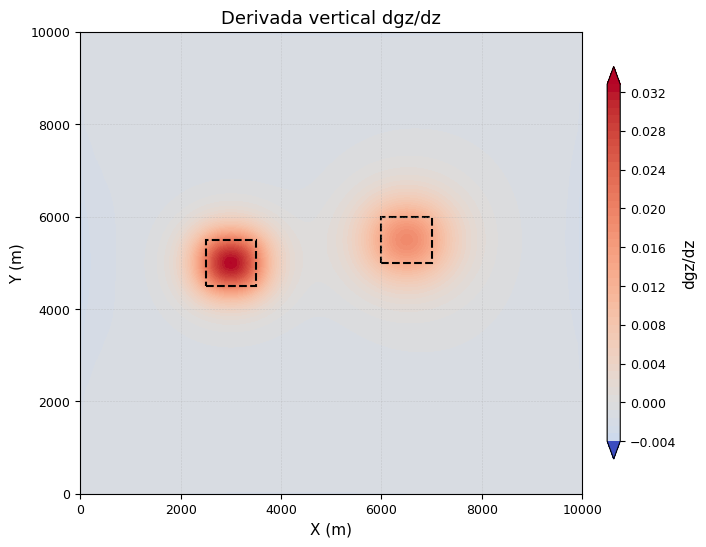

In [17]:
# ============================================================
# PLOT - DERIVADA VERTICAL dgz/dz
# ============================================================

fig_dz, ax_dz, cf_dz = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="dgz/dz",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Derivada vertical dgz/dz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dz,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [18]:
# ============================================================
# ETAPA 9 - GRADIENTE HORIZONTAL TOTAL DO gz
# ============================================================

hgm_gz = derivative.my_hgrad(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Gradiente horizontal total calculado com sucesso!")
print("HGM mínimo:", np.min(hgm_gz))
print("HGM máximo:", np.max(hgm_gz))
print("HGM médio:", np.mean(hgm_gz))

Gradiente horizontal total calculado com sucesso!
HGM mínimo: 1.130722366624987e-06
HGM máximo: 0.016006909844782046
HGM médio: 0.002366825656753039


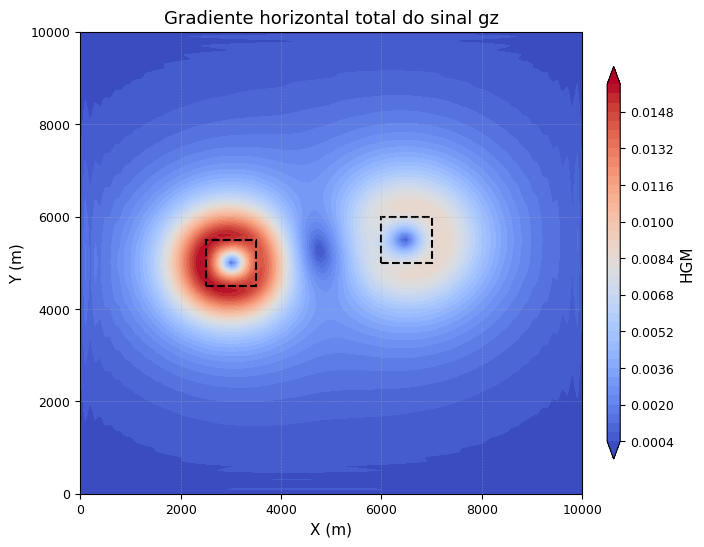

In [20]:
# ============================================================
# PLOT - GRADIENTE HORIZONTAL TOTAL
# ============================================================

fig_hgm, ax_hgm, cf_hgm = plotting.my_contourf(
    x=x,
    y=y,
    data=hgm_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="HGM",
    colormap="coolwarm",
    levels=50,
    title="Gradiente horizontal total do sinal gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_hgm,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [21]:
# ============================================================
# ETAPA 10 - SINAL ANALÍTICO DO gz
# ============================================================

asa_gz = derivative.my_totalgrad(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Sinal analítico calculado com sucesso!")
print("ASA mínimo:", np.min(asa_gz))
print("ASA máximo:", np.max(asa_gz))
print("ASA médio:", np.mean(asa_gz))

Sinal analítico calculado com sucesso!
ASA mínimo: 0.0005981169718848343
ASA máximo: 0.03290796309148527
ASA médio: 0.003313608057609601


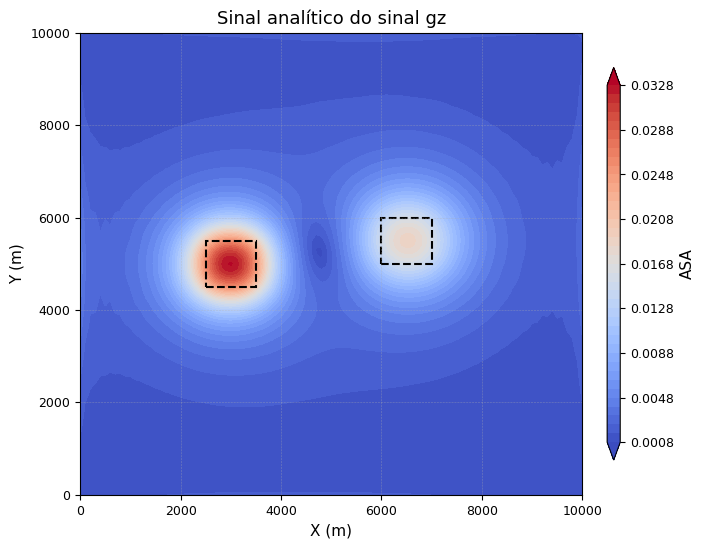

In [23]:
# ============================================================
# PLOT - SINAL ANALÍTICO
# ============================================================

fig_asa, ax_asa, cf_asa = plotting.my_contourf(
    x=x,
    y=y,
    data=asa_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="ASA",
    colormap="coolwarm",
    levels=50,
    title="Sinal analítico do sinal gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_asa,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [24]:
# ============================================================
# ETAPA 11 - THETA MAP DO gz
# ============================================================

theta_gz = filtering.my_thetamap(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Theta Map calculado com sucesso!")
print("Theta mínimo:", np.min(theta_gz))
print("Theta máximo:", np.max(theta_gz))
print("Theta médio:", np.mean(theta_gz))

Theta Map calculado com sucesso!
Theta mínimo: 0.00020803060970529775
Theta máximo: 1.5701856007938622
Theta médio: 0.7936410087927243


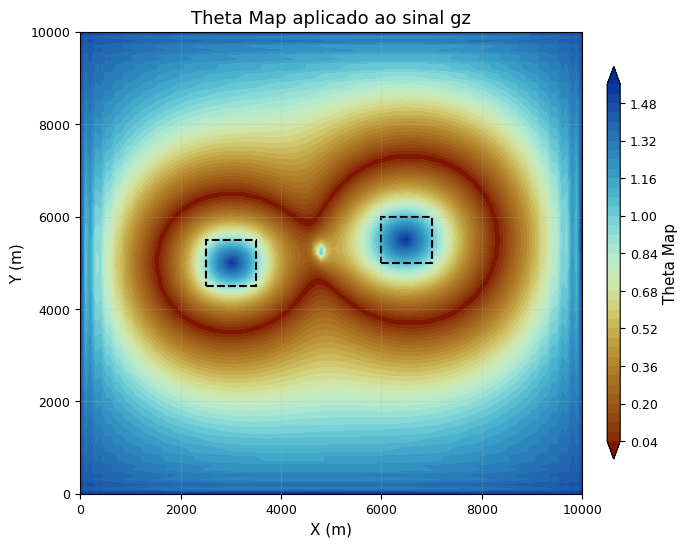

In [25]:
# ============================================================
# PLOT - THETA MAP
# ============================================================

fig_theta, ax_theta, cf_theta = plotting.my_contourf(
    x=x,
    y=y,
    data=theta_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Theta Map",
    colormap="roma",
    levels=50,
    title="Theta Map aplicado ao sinal gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_theta,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [27]:
# ============================================================
# ETAPA 12 - TILT ANGLE DA DERIVADA VERTICAL DO gz
# ============================================================

tilt_vdr_gz = filtering.my_tilt_vdr(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    degrees=True,
    flatten=False
)

print("Tilt angle da derivada vertical calculado com sucesso!")
print("Tilt VDR mínimo:", np.min(tilt_vdr_gz), "graus")
print("Tilt VDR máximo:", np.max(tilt_vdr_gz), "graus")
print("Tilt VDR médio:", np.mean(tilt_vdr_gz), "graus")

Tilt angle da derivada vertical calculado com sucesso!
Tilt VDR mínimo: -89.73287573949939 graus
Tilt VDR máximo: 89.8937850152164 graus
Tilt VDR médio: -38.2443221824907 graus


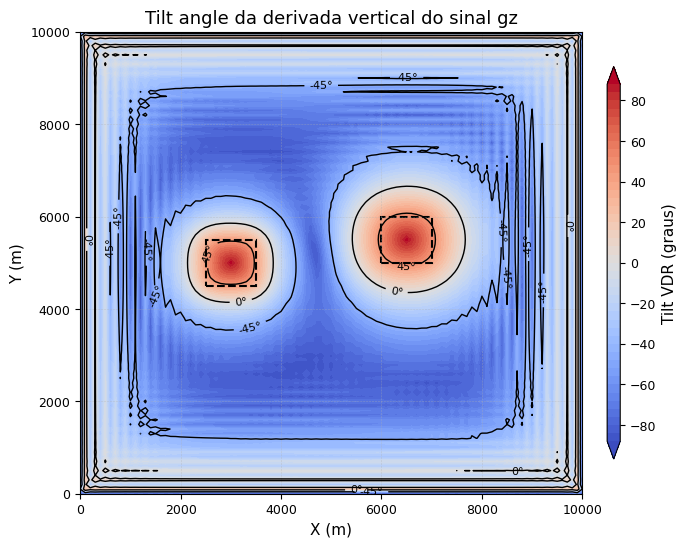

In [28]:
# ============================================================
# PLOT - TILT ANGLE DA DERIVADA VERTICAL
# ============================================================

fig_tilt_vdr, ax_tilt_vdr, cf_tilt_vdr = plotting.my_contourf(
    x=x,
    y=y,
    data=tilt_vdr_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Tilt VDR (graus)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Tilt angle da derivada vertical do sinal gz"
)

# Contornos interpretativos: -45°, 0° e +45°
plotting.my_contour(
    x=x,
    y=y,
    data=tilt_vdr_gz,
    ax=ax_tilt_vdr,
    levels=[-45, 0, 45],
    colors="black",
    linewidths=1.0,
    linestyles="-",
    clabel=True,
    clabel_fmt="%.0f°"
)

# Desenha a projeção horizontal dos prismas
for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_tilt_vdr,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [29]:
# ============================================================
# ETAPA 13 - THDR DO TILT ANGLE
# ============================================================

thdr_tilt_gz = filtering.my_thdr(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("THDR do Tilt calculado com sucesso!")
print("THDR mínimo:", np.min(thdr_tilt_gz))
print("THDR máximo:", np.max(thdr_tilt_gz))
print("THDR médio:", np.mean(thdr_tilt_gz))

THDR do Tilt calculado com sucesso!
THDR mínimo: 6.711393472823567e-06
THDR máximo: 0.006448256223678921
THDR médio: 0.0007679805196096298


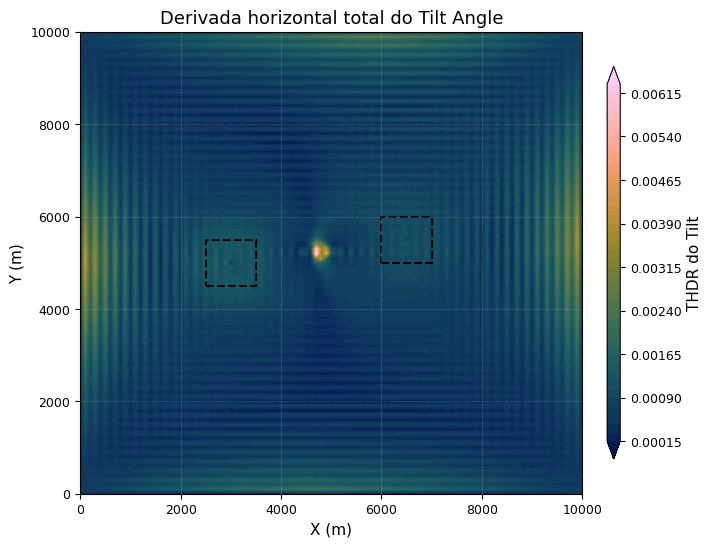

In [30]:
# ============================================================
# PLOT - THDR DO TILT ANGLE
# ============================================================

fig_thdr, ax_thdr, cf_thdr = plotting.my_contourf(
    x=x,
    y=y,
    data=thdr_tilt_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="THDR do Tilt",
    colormap="batlow",
    levels=50,
    title="Derivada horizontal total do Tilt Angle"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_thdr,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [31]:
# ============================================================
# ETAPA 14 - CONTINUAÇÃO ASCENDENTE DO gz
# ============================================================

# Alturas de continuação ascendente em metros
heights = [500.0, 1000.0, 2000.0]

# Dicionário para armazenar os resultados
gz_up = {}

for h in heights:
    gz_up[h] = filtering.my_continuation(
        x=x,
        y=y,
        data=gz,
        level=h,
        pad_factor=0.5,
        pad_mode="reflect",
        taper=True,
        flatten=False
    )

    print(f"Continuação ascendente calculada para h = {h} m")
    print("Mínimo:", np.min(gz_up[h]))
    print("Máximo:", np.max(gz_up[h]))
    print("Médio:", np.mean(gz_up[h]))
    print("-"*50)

Continuação ascendente calculada para h = 500.0 m
Mínimo: 0.857202952281118
Máximo: 11.894965608612459
Médio: 3.250405224936563
--------------------------------------------------
Continuação ascendente calculada para h = 1000.0 m
Mínimo: 1.274389458113477
Máximo: 8.042782142043372
Médio: 3.235137039862529
--------------------------------------------------
Continuação ascendente calculada para h = 2000.0 m
Mínimo: 1.90512535804729
Máximo: 5.201411901794102
Médio: 3.2018404781136502
--------------------------------------------------


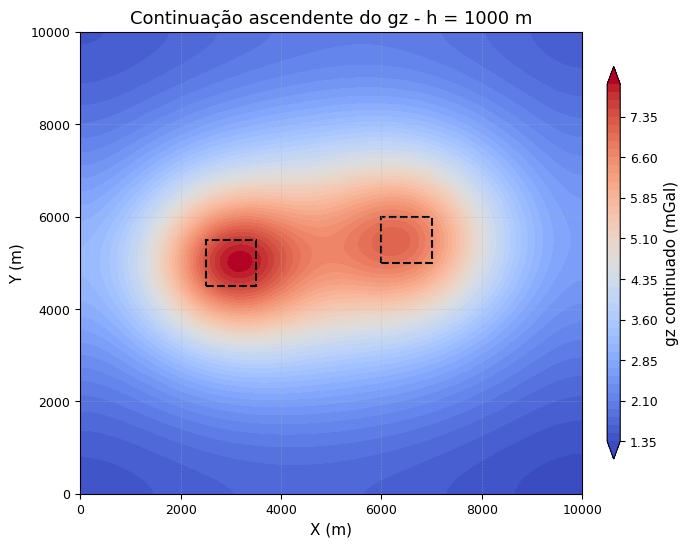

In [32]:
# ============================================================
# PLOT - CONTINUAÇÃO ASCENDENTE h = 1000 m
# ============================================================

h_plot = 1000.0

fig_up, ax_up, cf_up = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_up[h_plot],
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz continuado (mGal)",
    colormap="coolwarm",
    levels=50,
    title=f"Continuação ascendente do gz - h = {h_plot:.0f} m"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_up,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [33]:
# ============================================================
# ETAPA 15 - FILTRO PASSA-BAIXA GAUSSIANO
# ============================================================

# Comprimento de onda de corte em metros
wavelength_cut_low = 2000.0

gz_lowpass = filtering.my_lowpass_gaussian(
    x=x,
    y=y,
    data=gz,
    wavelength_cut=wavelength_cut_low,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Filtro passa-baixa calculado com sucesso!")
print("Mínimo:", np.min(gz_lowpass))
print("Máximo:", np.max(gz_lowpass))
print("Médio:", np.mean(gz_lowpass))

Filtro passa-baixa calculado com sucesso!
Mínimo: 0.39967885976441364
Máximo: 16.49060444643142
Médio: 3.2648644306547743


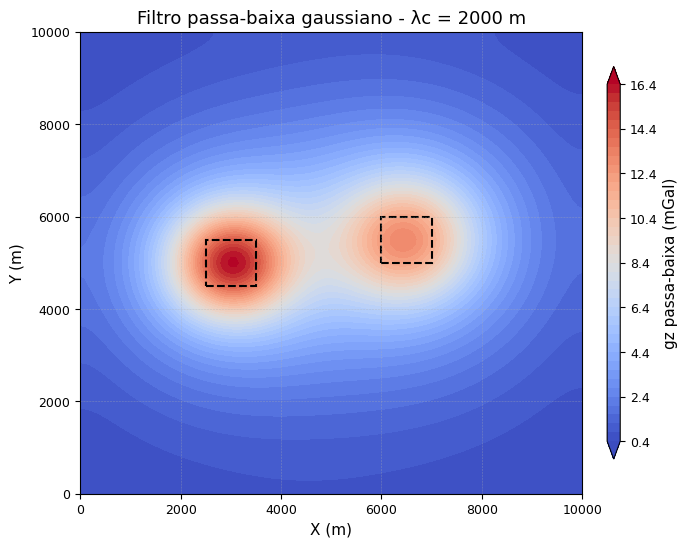

In [34]:
# ============================================================
# PLOT - PASSA-BAIXA GAUSSIANO
# ============================================================

fig_low, ax_low, cf_low = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_lowpass,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz passa-baixa (mGal)",
    colormap="coolwarm",
    levels=50,
    title=f"Filtro passa-baixa gaussiano - λc = {wavelength_cut_low:.0f} m"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_low,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [35]:
# ============================================================
# ETAPA 16 - FILTRO PASSA-ALTA GAUSSIANO
# ============================================================

# Comprimento de onda de corte em metros
wavelength_cut_high = 2000.0

gz_highpass = filtering.my_highpass_gaussian(
    x=x,
    y=y,
    data=gz,
    wavelength_cut=wavelength_cut_high,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Filtro passa-alta calculado com sucesso!")
print("Mínimo:", np.min(gz_highpass))
print("Máximo:", np.max(gz_highpass))
print("Médio:", np.mean(gz_highpass))

Filtro passa-alta calculado com sucesso!
Mínimo: -0.4848599066534085
Máximo: 5.3498920807259935
Médio: -0.0031551834501817996


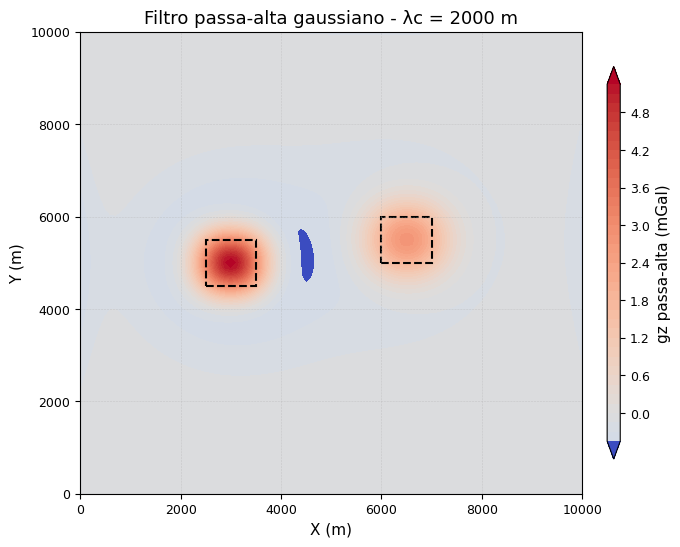

In [36]:
# ============================================================
# PLOT - PASSA-ALTA GAUSSIANO
# ============================================================

fig_high, ax_high, cf_high = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_highpass,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz passa-alta (mGal)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title=f"Filtro passa-alta gaussiano - λc = {wavelength_cut_high:.0f} m"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_high,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [37]:
# ============================================================
# ETAPA 17 - FILTRO PASSA-BANDA GAUSSIANO
# ============================================================

# Faixa de comprimentos de onda preservada
wavelength_min = 1000.0
wavelength_max = 4000.0

gz_bandpass = filtering.my_bandpass_gaussian(
    x=x,
    y=y,
    data=gz,
    wavelength_min=wavelength_min,
    wavelength_max=wavelength_max,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Filtro passa-banda calculado com sucesso!")
print("Mínimo:", np.min(gz_bandpass))
print("Máximo:", np.max(gz_bandpass))
print("Médio:", np.mean(gz_bandpass))

Filtro passa-banda calculado com sucesso!
Mínimo: -1.0285364000051511
Máximo: 9.148162229480153
Médio: -0.006643504140054706


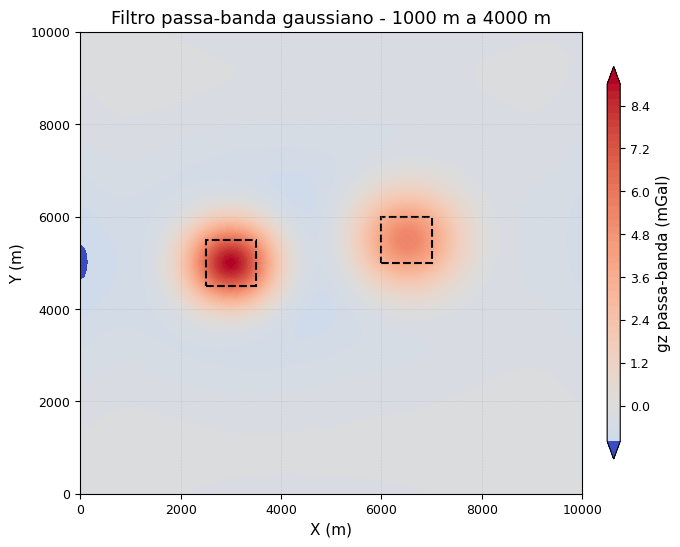

In [38]:
# ============================================================
# PLOT - PASSA-BANDA GAUSSIANO
# ============================================================

fig_band, ax_band, cf_band = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_bandpass,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz passa-banda (mGal)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title=f"Filtro passa-banda gaussiano - {wavelength_min:.0f} m a {wavelength_max:.0f} m"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_band,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [39]:
# ============================================================
# ETAPA 18 - SEGUNDA DERIVADA VERTICAL DO gz
# ============================================================

gz_dzz = derivative.my_zderiv(
    x=x,
    y=y,
    data=gz,
    n=2,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Segunda derivada vertical calculada com sucesso!")
print("d²gz/dz² mínimo:", np.min(gz_dzz))
print("d²gz/dz² máximo:", np.max(gz_dzz))
print("d²gz/dz² médio:", np.mean(gz_dzz))

Segunda derivada vertical calculada com sucesso!
d²gz/dz² mínimo: -3.1434619069193767e-05
d²gz/dz² máximo: 7.766592363015726e-05
d²gz/dz² médio: -2.052740207110226e-07


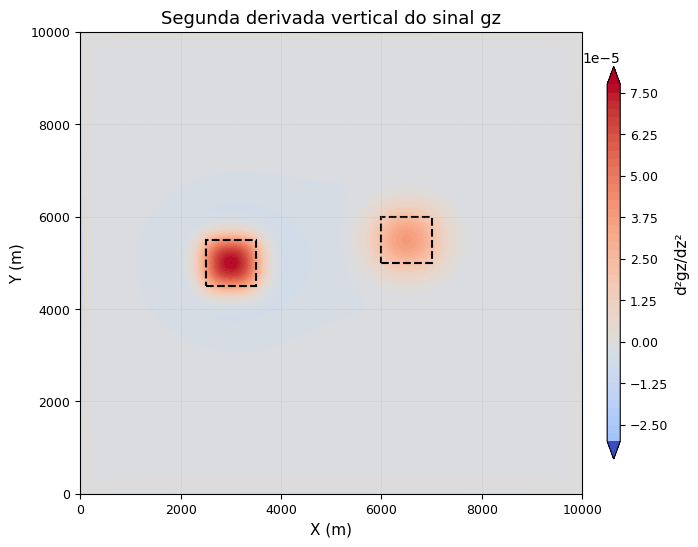

In [40]:
# ============================================================
# PLOT - SEGUNDA DERIVADA VERTICAL
# ============================================================

fig_dzz, ax_dzz, cf_dzz = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dzz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="d²gz/dz²",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Segunda derivada vertical do sinal gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dzz,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [41]:
# ============================================================
# ETAPA 19 - DERIVADAS DE SEGUNDA ORDEM EM x E y
# ============================================================

gz_dxx = derivative.my_xderiv(
    x=x,
    y=y,
    data=gz,
    n=2,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

gz_dyy = derivative.my_yderiv(
    x=x,
    y=y,
    data=gz,
    n=2,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivadas de segunda ordem calculadas com sucesso!")
print("d²gz/dx² mínimo:", np.min(gz_dxx))
print("d²gz/dx² máximo:", np.max(gz_dxx))
print("d²gz/dy² mínimo:", np.min(gz_dyy))
print("d²gz/dy² máximo:", np.max(gz_dyy))

Derivadas de segunda ordem calculadas com sucesso!
d²gz/dx² mínimo: -3.843171303992086e-05
d²gz/dx² máximo: 3.1783202582579886e-05
d²gz/dy² mínimo: -3.9234210590236395e-05
d²gz/dy² máximo: 1.434822536681154e-05


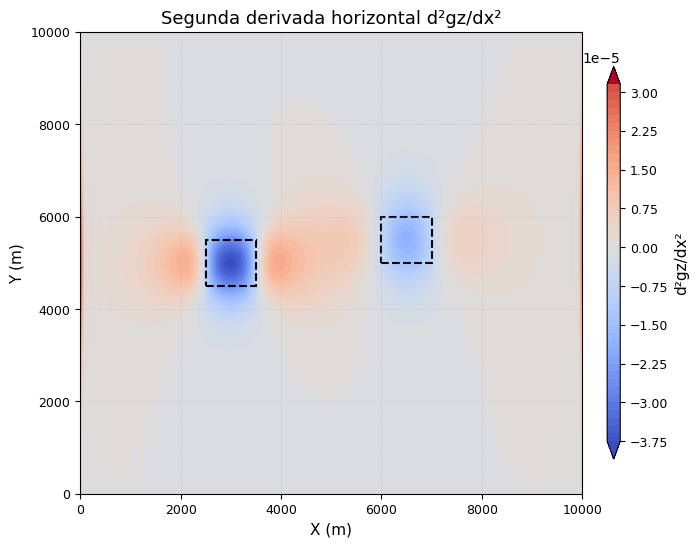

In [42]:
# ============================================================
# PLOT - d²gz/dx²
# ============================================================

fig_dxx, ax_dxx, cf_dxx = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dxx,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="d²gz/dx²",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Segunda derivada horizontal d²gz/dx²"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dxx,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

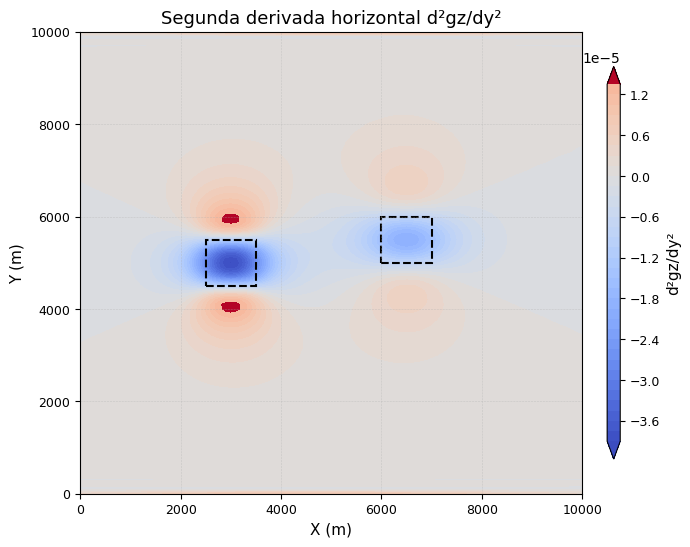

In [43]:
# ============================================================
# PLOT - d²gz/dy²
# ============================================================

fig_dyy, ax_dyy, cf_dyy = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dyy,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="d²gz/dy²",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Segunda derivada horizontal d²gz/dy²"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dyy,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [44]:
# ============================================================
# ETAPA 20 - LAPLACIANO HORIZONTAL DO gz
# ============================================================

gz_laplacian = gz_dxx + gz_dyy

print("Laplaciano horizontal calculado com sucesso!")
print("Laplaciano mínimo:", np.min(gz_laplacian))
print("Laplaciano máximo:", np.max(gz_laplacian))
print("Laplaciano médio:", np.mean(gz_laplacian))

Laplaciano horizontal calculado com sucesso!
Laplaciano mínimo: -7.766592363015726e-05
Laplaciano máximo: 3.1434619069193767e-05
Laplaciano médio: 2.052740207110225e-07


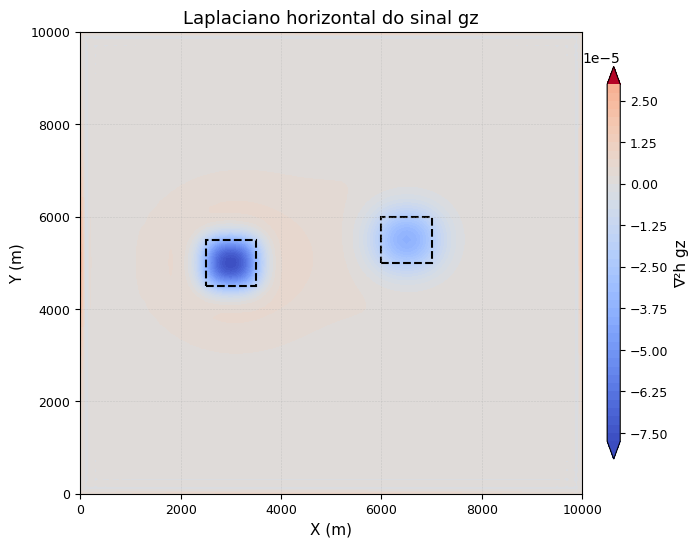

In [45]:
# ============================================================
# PLOT - LAPLACIANO HORIZONTAL
# ============================================================

fig_lap, ax_lap, cf_lap = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_laplacian,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="∇²h gz",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Laplaciano horizontal do sinal gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_lap,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [46]:
# ============================================================
# ETAPA 21 - DERIVADA DIRECIONAL DO gz
# ============================================================

# Azimute em graus
# 0°   -> direção y
# 90°  -> direção x
# 45°  -> direção diagonal
azimuth = 45.0

gz_dir = filtering.my_directional_derivative(
    x=x,
    y=y,
    data=gz,
    azimuth_degrees=azimuth,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Derivada direcional calculada com sucesso!")
print("Derivada direcional mínima:", np.min(gz_dir))
print("Derivada direcional máxima:", np.max(gz_dir))
print("Derivada direcional média:", np.mean(gz_dir))

Derivada direcional calculada com sucesso!
Derivada direcional mínima: -0.01444756123416589
Derivada direcional máxima: 0.015636055399077982
Derivada direcional média: 6.074191371767995e-06


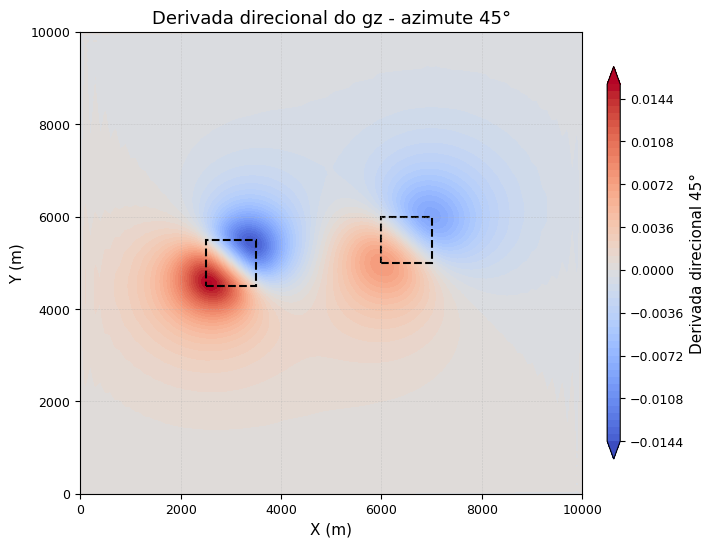

In [47]:
# ============================================================
# PLOT - DERIVADA DIRECIONAL
# ============================================================

fig_dir, ax_dir, cf_dir = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_dir,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label=f"Derivada direcional {azimuth:.0f}°",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title=f"Derivada direcional do gz - azimute {azimuth:.0f}°"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_dir,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [48]:
# ============================================================
# ETAPA 22 - COSSENO DO TILT ANGLE
# ============================================================

cos_tilt_gz = filtering.my_cos_tilt(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Cosseno do Tilt calculado com sucesso!")
print("Cos(Tilt) mínimo:", np.min(cos_tilt_gz))
print("Cos(Tilt) máximo:", np.max(cos_tilt_gz))
print("Cos(Tilt) médio:", np.mean(cos_tilt_gz))

Cosseno do Tilt calculado com sucesso!
Cos(Tilt) mínimo: 0.0006107259630690153
Cos(Tilt) máximo: 0.9999999783616328
Cos(Tilt) médio: 0.6386369063432237


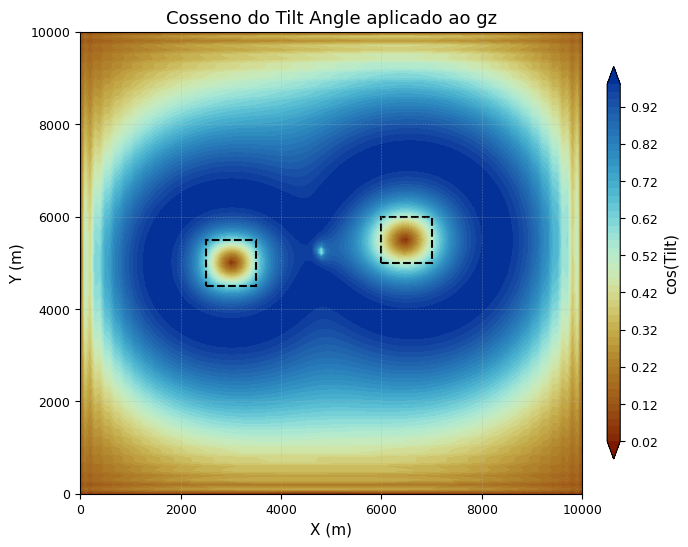

In [49]:
# ============================================================
# PLOT - COSSENO DO TILT ANGLE
# ============================================================

fig_cos_tilt, ax_cos_tilt, cf_cos_tilt = plotting.my_contourf(
    x=x,
    y=y,
    data=cos_tilt_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="cos(Tilt)",
    colormap="roma",
    levels=50,
    title="Cosseno do Tilt Angle aplicado ao gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_cos_tilt,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [50]:
# ============================================================
# ETAPA 23 - TILT HIPERBÓLICO
# ============================================================

hyper_tilt_gz = filtering.my_hyperbolictilt(
    x=x,
    y=y,
    data=gz,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Tilt hiperbólico calculado com sucesso!")
print("Tilt hiperbólico mínimo:", np.min(hyper_tilt_gz))
print("Tilt hiperbólico máximo:", np.max(hyper_tilt_gz))
print("Tilt hiperbólico médio:", np.mean(hyper_tilt_gz))

Tilt hiperbólico calculado com sucesso!
Tilt hiperbólico mínimo: -8.092563288004122
Tilt hiperbólico máximo: 4.488934366009845
Tilt hiperbólico médio: -0.907536157181333


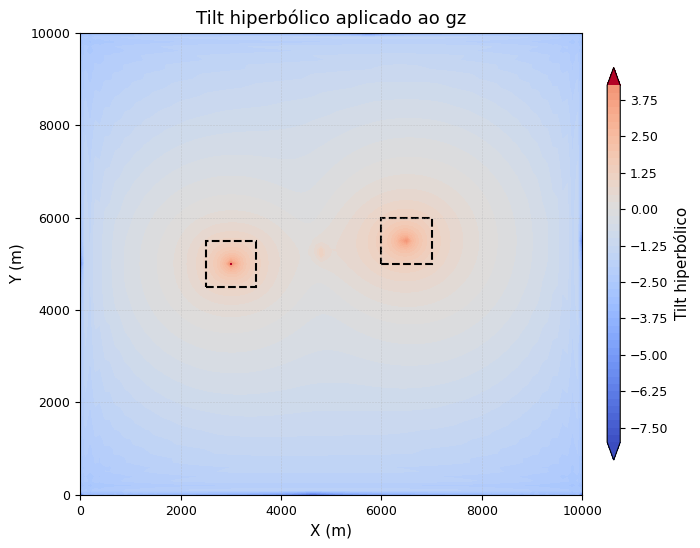

In [51]:
# ============================================================
# PLOT - TILT HIPERBÓLICO
# ============================================================

fig_hyper, ax_hyper, cf_hyper = plotting.my_contourf(
    x=x,
    y=y,
    data=hyper_tilt_gz,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="Tilt hiperbólico",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title="Tilt hiperbólico aplicado ao gz"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_hyper,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [52]:
# ============================================================
# ETAPA 24 - CONTINUAÇÃO DESCENDENTE REGULARIZADA
# ============================================================

# Distância de continuação descendente em metros
downward_height = 250.0

gz_down = filtering.my_downward_continuation_regularized(
    x=x,
    y=y,
    data=gz,
    height=downward_height,
    k_cut=None,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

print("Continuação descendente regularizada calculada com sucesso!")
print("Mínimo:", np.min(gz_down))
print("Máximo:", np.max(gz_down))
print("Médio:", np.mean(gz_down))

Continuação descendente regularizada calculada com sucesso!
Mínimo: -0.06656459714776553
Máximo: 31.80599617433612
Médio: 3.263343910815681


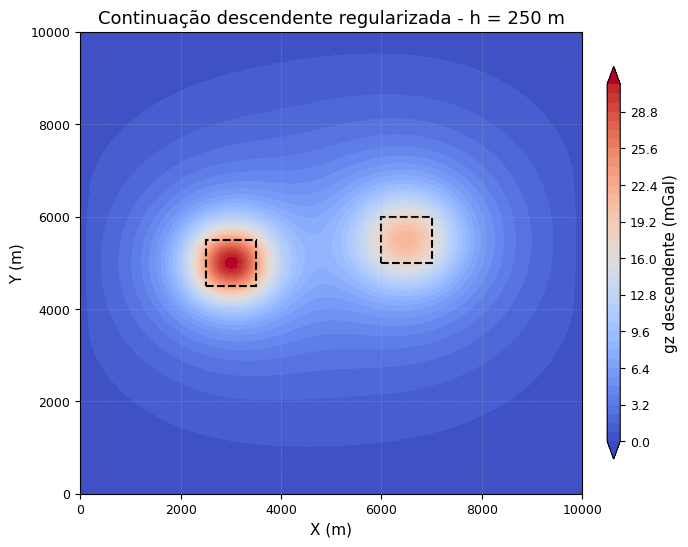

In [53]:
# ============================================================
# PLOT - CONTINUAÇÃO DESCENDENTE REGULARIZADA
# ============================================================

fig_down, ax_down, cf_down = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_down,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz descendente (mGal)",
    colormap="coolwarm",
    levels=50,
    title=f"Continuação descendente regularizada - h = {downward_height:.0f} m"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_down,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [58]:
# ============================================================
# ETAPA 25 - SEPARAÇÃO REGIONAL-RESIDUAL POR CONTINUAÇÃO ASCENDENTE
# ============================================================

# Altura usada para estimar o campo regional
regional_height = 1000.0

gz_regional = filtering.my_continuation(
    x=x,
    y=y,
    data=gz,
    level=regional_height,
    pad_factor=0.5,
    pad_mode="reflect",
    taper=True,
    flatten=False
)

gz_residual = gz - gz_regional

print("Separação regional-residual calculada com sucesso!")
print("Regional mínimo:", np.min(gz_regional))
print("Regional máximo:", np.max(gz_regional))
print("Residual mínimo:", np.min(gz_residual))
print("Residual máximo:", np.max(gz_residual))

Separação regional-residual calculada com sucesso!
Regional mínimo: 1.274389458113477
Regional máximo: 8.042782142043372
Residual mínimo: -1.6355634917303448
Residual máximo: 13.845750234126815


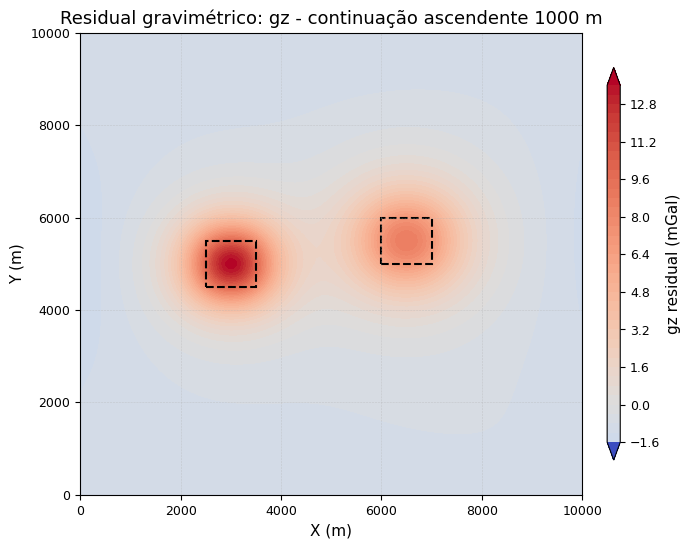

In [59]:
# ============================================================
# PLOT - RESIDUAL POR CONTINUAÇÃO ASCENDENTE
# ============================================================

fig_res, ax_res, cf_res = plotting.my_contourf(
    x=x,
    y=y,
    data=gz_residual,
    xlabel="X (m)",
    ylabel="Y (m)",
    colorbar_label="gz residual (mGal)",
    colormap="coolwarm",
    levels=50,
    center_zero=True,
    title=f"Residual gravimétrico: gz - continuação ascendente {regional_height:.0f} m"
)

for p in prisms:
    plotting.my_draw_rectangle(
        area=[p[0], p[1], p[2], p[3]],
        ax=ax_res,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5,
        linestyle="--"
    )

plt.show()

In [60]:
# ============================================================
# ETAPA 26 - SALVAR AS FIGURAS INDIVIDUAIS
# ============================================================

import os

# Pasta onde as figuras serão salvas
output_folder = "figuras_filtros"

os.makedirs(output_folder, exist_ok=True)

# Salvar figura do gz
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig01_gz_prismas.png"),
    fig=fig_gz
)

# Salvar figura do tilt angle
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig02_tilt_gz.png"),
    fig=fig_tilt
)

# Salvar derivadas horizontais
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig03_dgz_dx.png"),
    fig=fig_dx
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig04_dgz_dy.png"),
    fig=fig_dy
)

# Salvar derivada vertical
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig05_dgz_dz.png"),
    fig=fig_dz
)

# Salvar HGM
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig06_hgm_gz.png"),
    fig=fig_hgm
)

# Salvar sinal analítico
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig07_asa_gz.png"),
    fig=fig_asa
)

# Salvar theta map
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig08_theta_map_gz.png"),
    fig=fig_theta
)

# Salvar tilt da derivada vertical
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig09_tilt_vdr_gz.png"),
    fig=fig_tilt_vdr
)

# Salvar THDR do tilt
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig10_thdr_tilt_gz.png"),
    fig=fig_thdr
)

# Salvar continuação ascendente
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig11_upward_1000m_gz.png"),
    fig=fig_up
)

# Salvar filtros passa-baixa, passa-alta e passa-banda
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig12_lowpass_gz.png"),
    fig=fig_low
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig13_highpass_gz.png"),
    fig=fig_high
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig14_bandpass_gz.png"),
    fig=fig_band
)

# Salvar derivadas de segunda ordem
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig15_dzz_gz.png"),
    fig=fig_dzz
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig16_dxx_gz.png"),
    fig=fig_dxx
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig17_dyy_gz.png"),
    fig=fig_dyy
)

# Salvar laplaciano e derivada direcional
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig18_laplaciano_gz.png"),
    fig=fig_lap
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig19_derivada_direcional_gz.png"),
    fig=fig_dir
)

# Salvar cosseno do tilt, tilt hiperbólico, continuação descendente e residual
plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig20_cos_tilt_gz.png"),
    fig=fig_cos_tilt
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig21_hyperbolic_tilt_gz.png"),
    fig=fig_hyper
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig22_downward_gz.png"),
    fig=fig_down
)

plotting.my_save_figure(
    filename=os.path.join(output_folder, "fig23_residual_upward_gz.png"),
    fig=fig_res
)

print("Todas as figuras foram salvas com sucesso!")
print("Pasta de saída:", output_folder)

Todas as figuras foram salvas com sucesso!
Pasta de saída: figuras_filtros


In [63]:
# ============================================================
# ETAPA 27 - SALVAR OS DADOS NUMÉRICOS DOS FILTROS
# ============================================================

import os
import numpy as np

# Pasta onde os dados serão salvos
data_folder = "dados_filtros"

os.makedirs(data_folder, exist_ok=True)

# Função auxiliar para salvar dados no formato:
# x, y, valor
def salvar_mapa_txt(nome_arquivo, x, y, data):
    tabela = np.column_stack([
        x.ravel(),
        y.ravel(),
        data.ravel()
    ])
    
    caminho = os.path.join(data_folder, nome_arquivo)
    
    np.savetxt(
        caminho,
        tabela,
        #fmt="%.10e",
        fmt=["%.3f", "%.3f", "%.8f"],
        header="x y valor"
    )
    
    print("Arquivo salvo:", caminho)


# Campo original
salvar_mapa_txt("fig01_gz_prismas.txt", x, y, gz)

# Tilt angle
salvar_mapa_txt("fig02_tilt_gz.txt", x, y, tilt_gz)

# Derivadas horizontais
salvar_mapa_txt("fig03_dgz_dx.txt", x, y, gz_dx)
salvar_mapa_txt("fig04_dgz_dy.txt", x, y, gz_dy)

# Derivada vertical
salvar_mapa_txt("fig05_dgz_dz.txt", x, y, gz_dz)

# HGM
salvar_mapa_txt("fig06_hgm_gz.txt", x, y, hgm_gz)

# Sinal analítico
salvar_mapa_txt("fig07_asa_gz.txt", x, y, asa_gz)

# Theta map
salvar_mapa_txt("fig08_theta_map_gz.txt", x, y, theta_gz)

# Tilt da derivada vertical
salvar_mapa_txt("fig09_tilt_vdr_gz.txt", x, y, tilt_vdr_gz)

# THDR do tilt
salvar_mapa_txt("fig10_thdr_tilt_gz.txt", x, y, thdr_tilt_gz)

# Continuação ascendente
salvar_mapa_txt("fig11_upward_1000m_gz.txt", x, y, gz_up[1000.0])

# Passa-baixa, passa-alta e passa-banda
salvar_mapa_txt("fig12_lowpass_gz.txt", x, y, gz_lowpass)
salvar_mapa_txt("fig13_highpass_gz.txt", x, y, gz_highpass)
salvar_mapa_txt("fig14_bandpass_gz.txt", x, y, gz_bandpass)

# Derivadas de segunda ordem
salvar_mapa_txt("fig15_dzz_gz.txt", x, y, gz_dzz)
salvar_mapa_txt("fig16_dxx_gz.txt", x, y, gz_dxx)
salvar_mapa_txt("fig17_dyy_gz.txt", x, y, gz_dyy)

# Laplaciano e derivada direcional
salvar_mapa_txt("fig18_laplaciano_gz.txt", x, y, gz_laplacian)
salvar_mapa_txt("fig19_derivada_direcional_gz.txt", x, y, gz_dir)

# Cosseno do tilt, tilt hiperbólico, continuação descendente e residual
salvar_mapa_txt("fig20_cos_tilt_gz.txt", x, y, cos_tilt_gz)
salvar_mapa_txt("fig21_hyperbolic_tilt_gz.txt", x, y, hyper_tilt_gz)
salvar_mapa_txt("fig22_downward_gz.txt", x, y, gz_down)
salvar_mapa_txt("fig23_residual_upward_gz.txt", x, y, gz_residual)

print("\nTodos os dados numéricos foram salvos com sucesso!")
print("Pasta de saída:", data_folder)

Arquivo salvo: dados_filtros\fig01_gz_prismas.txt
Arquivo salvo: dados_filtros\fig02_tilt_gz.txt
Arquivo salvo: dados_filtros\fig03_dgz_dx.txt
Arquivo salvo: dados_filtros\fig04_dgz_dy.txt
Arquivo salvo: dados_filtros\fig05_dgz_dz.txt
Arquivo salvo: dados_filtros\fig06_hgm_gz.txt
Arquivo salvo: dados_filtros\fig07_asa_gz.txt
Arquivo salvo: dados_filtros\fig08_theta_map_gz.txt
Arquivo salvo: dados_filtros\fig09_tilt_vdr_gz.txt
Arquivo salvo: dados_filtros\fig10_thdr_tilt_gz.txt
Arquivo salvo: dados_filtros\fig11_upward_1000m_gz.txt
Arquivo salvo: dados_filtros\fig12_lowpass_gz.txt
Arquivo salvo: dados_filtros\fig13_highpass_gz.txt
Arquivo salvo: dados_filtros\fig14_bandpass_gz.txt
Arquivo salvo: dados_filtros\fig15_dzz_gz.txt
Arquivo salvo: dados_filtros\fig16_dxx_gz.txt
Arquivo salvo: dados_filtros\fig17_dyy_gz.txt
Arquivo salvo: dados_filtros\fig18_laplaciano_gz.txt
Arquivo salvo: dados_filtros\fig19_derivada_direcional_gz.txt
Arquivo salvo: dados_filtros\fig20_cos_tilt_gz.txt
Arquivo